In [1]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import IncrementalPCA
import math
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from kaggle_secrets import UserSecretsClient
import shutil
from sklearn.preprocessing import StandardScaler
import time
import json
from datetime import datetime
from sklearn.impute import KNNImputer
import polars as pl
import zoneinfo

In [2]:
def get_dtime():
    moscow_tz = zoneinfo.ZoneInfo("Europe/Moscow")
    now = datetime.now(moscow_tz)
    return now.strftime("%d-%m-%H-%M-%S")

In [3]:
def plot_histogram(data, bin_width=None, bins='auto', title='Гистограмма', 
                   xlabel='Значения', ylabel='Частота', figsize=(10, 6)):
    
    plt.figure(figsize=figsize)
    
    # Если указана ширина бина, рассчитываем количество бинов
    if bin_width is not None:
        data_range = np.max(data) - np.min(data)
        bins = int(np.ceil(data_range / bin_width))
    
    # Построение гистограммы
    plt.hist(data, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
    
    # Настройка графика
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [4]:
def plot_correlation_matrix(df, figsize=(12, 10), cmap='coolwarm', 
                           annot=False, fmt='.2f', title='Correlation Matrix'):

    
    # Выбираем только числовые колонки
    numeric_df = df.select_dtypes(include=[np.number])
    
    if len(numeric_df.columns) < 2:
        print("Ошибка: нужно как минимум 2 числовых признака")
        return None
    
    # Расчет матрицы корреляций
    corr_matrix = numeric_df.corr()
    
    # Построение тепловой карты
    plt.figure(figsize=figsize)
    
    # Маска для верхнего треугольника
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=annot, 
                fmt=fmt, 
                cmap=cmap,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8, 'label': 'Correlation'},
                vmin=-1, vmax=1,
                annot_kws={'size': 8})
    
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    #plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.xticks([])
    plt.yticks([])
    #plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()
    
    return corr_matrix

# Hyperparameters

In [5]:
threshold = 0.8 # max na_ratio in column that we can allow (drop otherwise)
pca_n_comp = 600 
fillna_strategy = 'mean' # zero or mean 

do_pca = True
do_scale= True

In [6]:
root = "/kaggle/input/datasets/lolikion228/some-serious-shit/data/"

# Train data preprocessing

# Numerical features

In [7]:
train_extra_feats = pl.scan_parquet(root + "train_extra_features.parquet").drop('customer_id')

In [9]:
missing_percent = train_extra_feats.select(pl.all().null_count() / pl.len()).collect()
frac_values = missing_percent.row(0)

In [10]:
good_cols = [col for col,frac in zip(missing_percent.columns,frac_values) if frac<threshold]

In [11]:
train_extra_feats = train_extra_feats.drop([col for col in missing_percent.columns if col not in good_cols])

In [12]:
train_extra_feats = train_extra_feats.cast(pl.Float32)

In [13]:
len(train_extra_feats.collect_schema().names())

1330

In [14]:
train_extra_feats = train_extra_feats.collect().to_pandas()

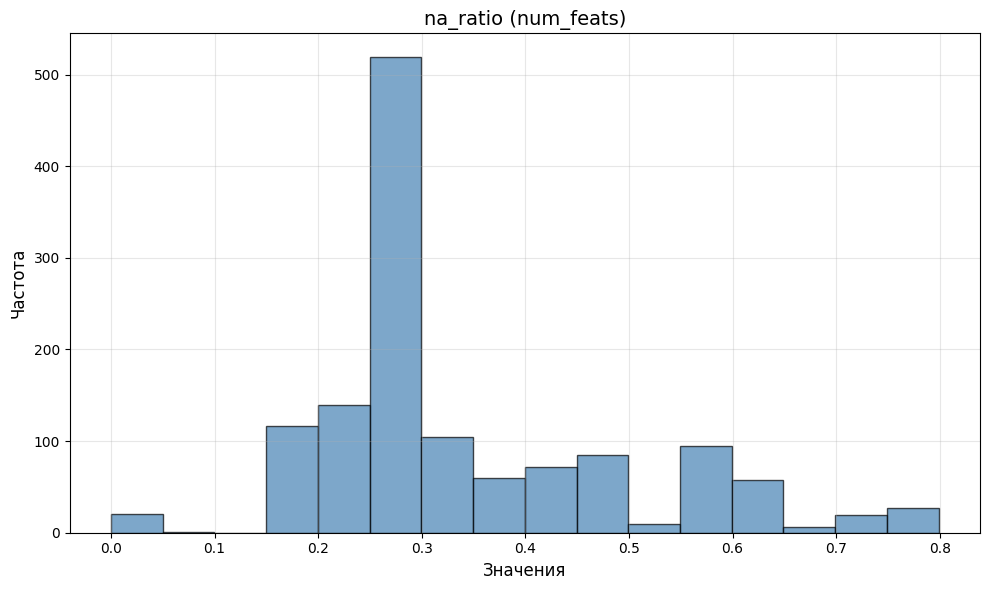

In [15]:
na_ratio = train_extra_feats.isna().mean()
plot_histogram(na_ratio, bin_width=0.05, title="na_ratio (num_feats)")

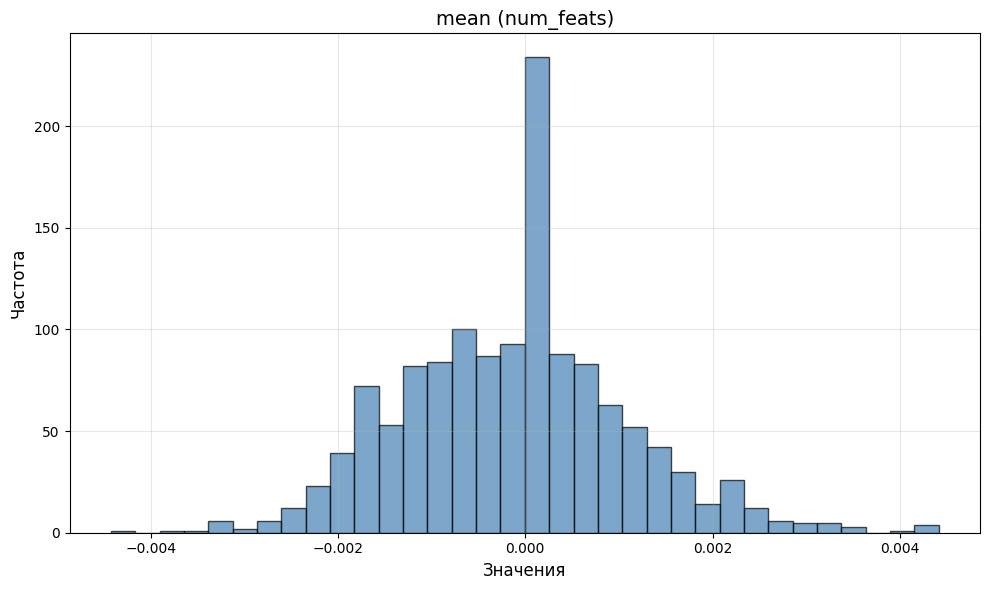

In [16]:
mean = train_extra_feats.mean(axis=0)
plot_histogram(mean,  title="mean (num_feats)")
del mean

In [17]:
std = train_extra_feats.std(axis=0)

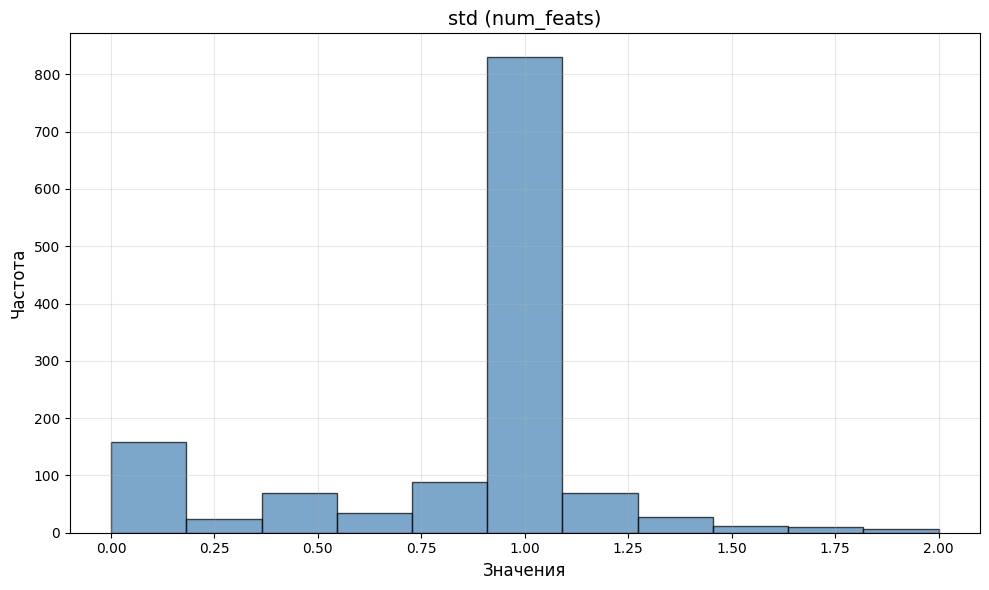

In [18]:
plot_histogram(std, bin_width=0.2, title="std (num_feats)")

In [19]:
small_std = std[std<=1e-3].index.to_list()
train_extra_feats = train_extra_feats.drop(small_std, axis=1)

In [20]:
if fillna_strategy == 'mean':
    old_mean = train_extra_feats.mean()
    num_feats_cleaned = train_extra_feats.fillna(old_mean)
elif fillna_strategy == 'zero':
    num_feats_cleaned = train_extra_feats.fillna(0)
else:
    raise Exception("invalid")

del train_extra_feats
num_feats_cleaned.isna().sum().sum()

np.int64(0)

In [21]:
num_feats_cleaned.shape

(750000, 1200)

In [22]:
if do_scale:
    scaler = StandardScaler()
    num_feats_cleaned = scaler.fit_transform(num_feats_cleaned)

In [23]:
if do_pca:
    ipca = IncrementalPCA()
    # 400 seconds
    ipca.fit(num_feats_cleaned)

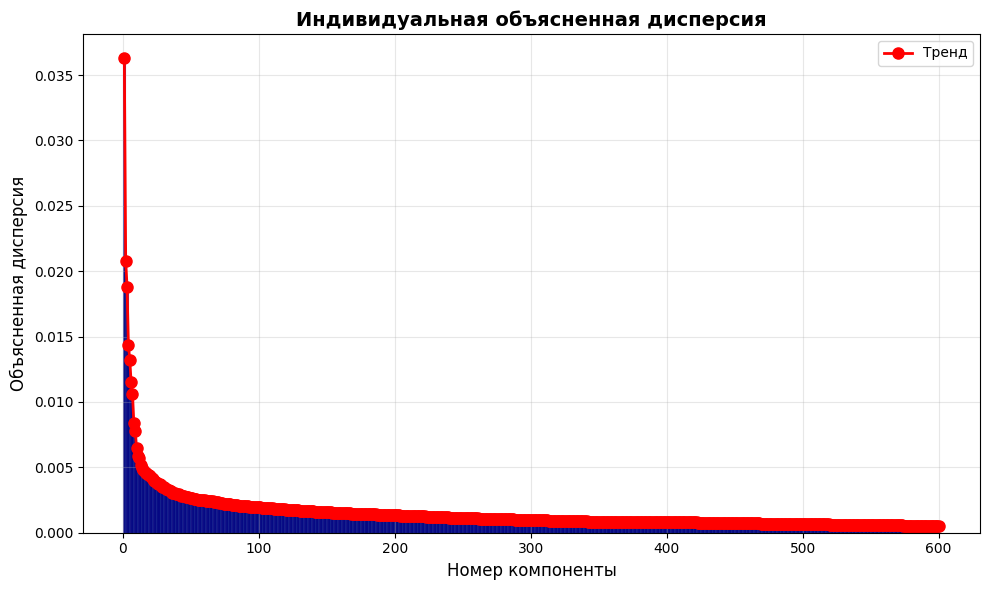

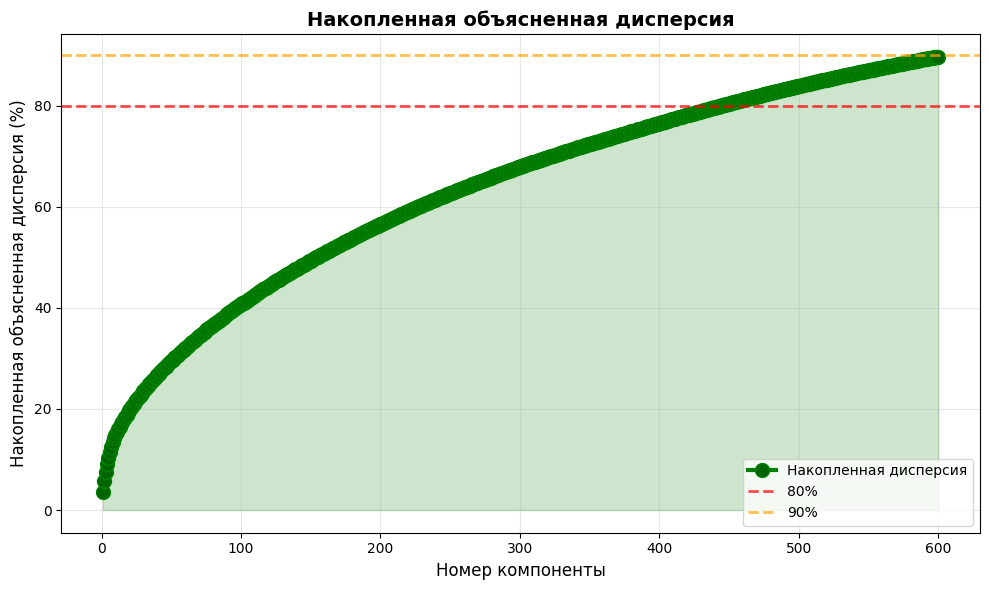

In [24]:
if do_pca:
    explained_variance = ipca.explained_variance_ratio_[:pca_n_comp]
    cumulative_variance = np.cumsum(explained_variance)
    components = np.arange(1, len(explained_variance) + 1)
    
    # ГРАФИК 1: Индивидуальная объясненная дисперсия
    plt.figure(figsize=(10, 6))
    bars = plt.bar(components, explained_variance, alpha=0.7, 
                   color='steelblue', edgecolor='navy', linewidth=1.5)
    plt.plot(components, explained_variance, 'ro-', linewidth=2, markersize=8, 
             label='Тренд', markerfacecolor='red')
    
    
    plt.xlabel('Номер компоненты', fontsize=12)
    plt.ylabel('Объясненная дисперсия', fontsize=12)
    plt.title('Индивидуальная объясненная дисперсия', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    #plt.xticks(components)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # ГРАФИК 2: Накопленная объясненная дисперсия
    plt.figure(figsize=(10, 6))
    plt.plot(components, cumulative_variance * 100, 'go-', linewidth=3, 
             markersize=10, label='Накопленная дисперсия', markerfacecolor='darkgreen')
    plt.fill_between(components, 0, cumulative_variance * 100, 
                     alpha=0.2, color='green')
    
    # Добавление пороговых линий
    plt.axhline(y=80, color='red', linestyle='--', linewidth=2, alpha=0.7, label='80%')
    plt.axhline(y=90, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='90%')
    
    
    plt.xlabel('Номер компоненты', fontsize=12)
    plt.ylabel('Накопленная объясненная дисперсия (%)', fontsize=12)
    plt.title('Накопленная объясненная дисперсия', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    #plt.xticks(components)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

In [25]:
if do_pca:
    num_encoded = np.zeros( (num_feats_cleaned.shape[0],pca_n_comp), dtype=np.float32)
    N = 10
    ix = np.array_split(np.array(range(num_feats_cleaned.shape[0])), N)
    
    for i in ix:
        num_encoded[i, :] = ipca.transform(num_feats_cleaned[i,:])[:,:pca_n_comp]
    del num_feats_cleaned
else:
    num_encoded = num_feats_cleaned

In [26]:
X = pd.DataFrame(num_encoded).astype('float32')
del num_encoded

In [27]:
X.shape

(750000, 600)

# Test data preprocessing

# Numerical

In [28]:
test_extra_feats = pl.scan_parquet(root + "test_extra_features.parquet")

In [29]:
test_extra_feats = test_extra_feats.cast(pl.Float32)

In [30]:
test_extra_feats = test_extra_feats.select(good_cols).collect().to_pandas()

In [31]:
test_extra_feats = test_extra_feats.drop(small_std, axis=1)

In [32]:
if fillna_strategy == 'mean':
    test_extra_feats_cleaned = test_extra_feats.fillna(old_mean)
elif fillna_strategy == 'zero':
    test_extra_feats_cleaned = test_extra_feats.fillna(0)
else:
    raise Exception("invalid")
del test_extra_feats
test_extra_feats_cleaned.isna().sum().sum()

np.int64(0)

In [33]:
if do_scale:
    test_extra_feats_cleaned = scaler.transform(test_extra_feats_cleaned)

In [34]:
if do_pca:
    test_extra_feats_cleaned = ipca.transform(test_extra_feats_cleaned)[:,:pca_n_comp]

In [35]:
X_test = pd.DataFrame(test_extra_feats_cleaned).astype('float32')
del test_extra_feats_cleaned

In [36]:
X_test.shape

(250000, 600)

# Vibe check

In [37]:
X

,0,1,2,3,4,5,6,7,8,9,...,590,591,592,593,594,595,596,597,598,599
0,-1.143104,0.406905,-3.060505,0.270544,-0.815834,-1.338024,-0.358524,-0.660607,-0.512500,0.591890,...,-0.026283,0.029939,0.103582,-0.104088,0.008398,-0.457848,-0.132452,-0.453064,0.015730,-0.258290
1,2.892578,11.284656,4.785743,-0.513451,-0.652034,-1.236176,0.009775,2.058395,0.875985,-3.555056,...,0.053781,0.524578,0.992539,0.701089,-0.461157,0.121458,-0.110940,-1.031646,-1.042296,0.981991
2,-1.030338,-1.581554,-5.292281,-0.087234,-0.111194,-1.296677,0.113615,-1.045868,-0.006404,1.074796,...,0.185218,0.258298,-0.460375,0.249744,-0.399475,-0.195177,0.378823,-0.023642,-0.101496,0.898337
3,0.067826,0.776662,-4.208234,0.676777,0.113743,-2.038375,-0.098794,-0.011122,0.274588,0.087231,...,0.405874,0.177582,0.121653,-0.159323,0.046737,-0.150164,-0.237838,-0.113275,0.106213,0.133655
4,-0.970026,-1.787611,-1.804669,0.921566,-0.469990,-2.440563,0.088529,-0.936277,-0.709939,0.544466,...,-0.144739,-0.485620,-0.047859,0.675797,-0.436380,0.279664,0.132402,-0.398413,0.062728,-0.099592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,0.034707,0.139714,-1.063121,0.009179,0.206418,0.630462,-0.048510,-0.418225,-1.050484,-0.196574,...,-0.547799,0.407830,-0.053919,0.027603,0.060425,-0.499611,0.227047,0.129438,-0.154605,-0.400830
749996,-1.041047,0.401074,-2.427154,0.128770,0.039589,0.685851,-0.434411,-0.407015,-0.176021,0.267886,...,0.109729,0.159140,-0.526307,0.140911,-0.016377,-0.239775,-0.526525,0.325105,-0.054680,-0.588618
749997,-1.548402,-2.184632,-1.051516,-0.471512,-0.328612,0.164386,0.183752,-0.940665,-0.468765,0.571373,...,0.177664,0.334492,0.132396,-0.307169,0.066352,-0.220156,0.146359,0.200666,-0.193145,0.279442
749998,-1.049682,0.523735,-3.779902,0.031814,-0.319921,2.245538,-0.411726,-0.772462,-1.132152,0.179180,...,0.547199,-0.106864,-0.154020,0.181167,0.371612,0.705789,0.035050,-0.222871,0.953657,1.803806


In [38]:
X_test

,0,1,2,3,4,5,6,7,8,9,...,590,591,592,593,594,595,596,597,598,599
0,-0.941605,-0.323634,-3.618085,0.101892,-0.383979,-0.252571,-0.036841,-0.100195,-0.111685,1.040140,...,-0.062984,-1.028806,-0.667324,0.029776,-1.184865,-0.741266,-0.534239,-0.153795,-0.326492,-0.661309
1,-1.583827,-1.960212,-1.724257,-0.171535,-0.453967,-0.655718,0.070758,-0.943381,0.090445,1.782507,...,-0.327837,-0.016032,-0.449309,-0.235782,0.127784,-0.725826,-0.106887,-0.856616,-0.219476,0.368304
2,-0.958974,0.564788,-3.402275,0.201731,-0.175864,1.009074,-0.304601,-0.292393,-0.208003,0.034059,...,-0.480117,-0.648809,-0.127617,-0.066363,-0.126799,-0.133477,-0.222420,-0.013249,-0.300545,-0.014141
3,0.052890,0.241143,-1.426009,-0.076007,0.289469,1.736005,-0.154571,-0.396176,-0.501569,0.858087,...,-0.188478,0.363577,0.270291,-0.234847,0.151971,-0.265849,-0.481226,-0.080842,-0.042742,0.220537
4,-1.249310,-0.737962,2.766663,-0.486601,-2.061611,-3.845473,-0.183576,-1.408839,-1.459175,1.049752,...,0.294644,-0.214187,0.068210,0.135260,0.128283,0.790246,-0.181319,0.733053,-0.632129,0.305713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,0.002234,-0.015596,-0.096688,0.005836,0.006646,0.044983,-0.007403,-0.093229,-0.090399,0.079207,...,0.002341,-0.012674,-0.001907,0.005811,-0.003477,0.001494,0.000345,0.005847,0.021393,-0.024097
249996,-1.156543,-0.011288,-0.299600,1.753475,0.089848,-2.942000,-0.204754,1.091011,0.255771,-0.795507,...,0.030695,-0.338787,-0.776624,0.381173,0.111145,0.281100,-0.124918,-0.254117,0.651476,0.146264
249997,0.008385,0.043431,-0.617490,-0.146088,-0.040632,0.164713,-0.056101,-0.444249,-0.822302,0.235184,...,0.011558,-0.147670,0.209488,-0.063635,0.006298,-0.043384,-0.103875,0.041428,-0.175256,0.122601
249998,-1.100206,0.108320,-1.009980,-0.135917,-0.419648,0.623749,-0.279602,-0.504462,-1.144928,-0.397879,...,0.091376,0.069688,0.257851,-0.130041,0.333987,0.204229,0.016075,0.003070,0.094401,0.533076


# Dataset creation

In [39]:
description = f"""
na_threshold = {threshold}\n
pca_n_comp = {pca_n_comp}\n
fillna_strategy = {fillna_strategy}\n
do_pca = {do_pca}\n
do_scale = {do_scale}
"""

In [40]:
KAGGLE_USERNAME = "Lolikion228"  
DATASET_NAME = f"hack-extra-feats-{get_dtime()}"
DATASET_FOLDER = "/kaggle/working/my_dataset"
DATA_SUBFOLDER = "data"
FULL_DATA_PATH = os.path.join(DATASET_FOLDER, DATA_SUBFOLDER)

if os.path.exists(DATASET_FOLDER):
    shutil.rmtree(DATASET_FOLDER)
os.makedirs(FULL_DATA_PATH)

metadata = {
    "title": DATASET_NAME,  
    "id": f"{KAGGLE_USERNAME}/{DATASET_NAME}",  
    "licenses": [{"name": "CC0-1.0"}],
    "description": description,
}

metadata_path = os.path.join(DATASET_FOLDER, 'dataset-metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

In [41]:
X.to_parquet(FULL_DATA_PATH + f'/train_extra_feats.parquet')
X_test.to_parquet(FULL_DATA_PATH + f'/test_extra_feats.parquet')

In [42]:
user_secrets = UserSecretsClient()
api_token = user_secrets.get_secret("api_key")

In [43]:
os.environ['KAGGLE_API_TOKEN'] = api_token 
os.environ['KAGGLE_USERNAME'] = "Lolikion228"
os.environ['KAGGLE_KEY'] = api_token

In [44]:
!kaggle datasets create -p "{DATASET_FOLDER}" -r tar

Starting upload for file data.tar
100%|███████████████████████████████████████| 2.90G/2.90G [00:20<00:00, 150MB/s]
Upload successful: data.tar (3GB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/lolikion228/hack-extra-feats-25-02-10-35-13
